# Живородени деца в България — Анализ на данни
### Курс: Math Concepts for Developers

Тук зареждаме данни от три Excel файла, публикувани от НСИ (Национален статистически институт), и ги показваме в табличен вид.

## 1. Живородени по пол — таблица

In [84]:
import pandas as pd

df = pd.read_excel(
    r"C:\Users\sasho kravaikov\Desktop\live_births\Live_births_by_districts_municipalities_and_sex.xlsx"
)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)


print(df)

      Области, Общини   общо момчета момичета
0    Общо за страната  53428   27377    26051
1         Благоевград   2303    1188     1115
2              Банско     89      50       39
3              Белица     86      50       36
4         Благоевград    569     291      278
5         Гоце Делчев    253     129      124
6              Гърмен    160      84       76
7              Кресна     32      16       16
8              Петрич    385     199      186
9              Разлог    140      70       70
10          Сандански    253     133      120
11            Сатовча     76      41       35
12            Симитли     96      46       50
13           Струмяни     45      18       27
14        Хаджидимово     50      25       25
15            Якоруда     69      36       33
16             Бургас   3037    1540     1497
17              Айтос    214     125       89
18             Бургас   1499     758      741
19             Камено     97      50       47
20           Карнобат    165      

In [85]:
def top_10_cities_by_births(df, place_col='Области, Общини', births_col='общо'):
    """Връща топ 10 населени места по брой живородени."""
    data = df[[place_col, births_col]].copy()
    data[births_col] = pd.to_numeric(data[births_col], errors='coerce')
    data = data.dropna(subset=[births_col])

    # Премахваме обобщения ред за страната
    data = data[~data[place_col].astype(str).str.contains(r'^\s*Общо за страната\s*$', regex=True)]

    top10 = data.sort_values(by=births_col, ascending=False).head(10).reset_index(drop=True)
    top10.index = top10.index + 1
    return top10


top10_cities = top_10_cities_by_births(df)
print('Топ 10 населени места по живородени:')
print(top10_cities.to_string())

Топ 10 населени места по живородени:
   Области, Общини     общо
1            София  12025.0
2          Пловдив   5804.0
3            Варна   3632.0
4          Пловдив   3096.0
5           Бургас   3037.0
6            Варна   2688.0
7     Стара Загора   2546.0
8      Благоевград   2303.0
9           Сливен   2117.0
10       Пазарджик   1943.0


Написах функция която извлича редовете с 10 най-големи резултати, но това не е коректно тъйкато таблицата съдържа обобщени данни за области и общини. 

In [86]:
def select_places_by_level(
    df,
    level='area',
    place_col='Области, Общини',
    births_col='общо',
):
    """
    Оставя по един ред за всяко име.
    level='area' -> взема по-малката стойност (Община)
    level='municipality' -> взема по-голямата стойност (Област)
    """
    data = df[[place_col, births_col]].copy()
    data[births_col] = pd.to_numeric(data[births_col], errors='coerce')
    data = data.dropna(subset=[births_col])
    data = data[data[place_col].astype(str).str.strip() != 'Общо за страната']

    if level == 'area':
        selected_idx = data.groupby(place_col)[births_col].idxmin()
    elif level == 'municipality':
        selected_idx = data.groupby(place_col)[births_col].idxmax()
    else:
        raise ValueError("level трябва да е 'area' или 'municipality'")

    result = data.loc[selected_idx].copy()
    result = result.sort_values(by=births_col, ascending=False).reset_index(drop=True)
    return result


def top_n_places_by_births(
    df,
    n=10,
    level='area',
    place_col='Области, Общини',
    births_col='общо',
):
    """Връща топ N Общини по брой живородени."""
    result = select_places_by_level(
        df,
        level=level,
        place_col=place_col,
        births_col=births_col,
    ).head(n)
    result.index = result.index + 1
    return result


top10_areas = top_n_places_by_births(df, n=10, level='area')
print('Топ 10 общини по живородени:')
print(top10_areas.to_string())

print('\nТоп 10 области по живорoдени:')
print(top_n_places_by_births(df, n=10, level='municipality').to_string())



Топ 10 общини по живородени:
   Области, Общини    общо
1          Пловдив  3096.0
2            Варна  2688.0
3            София  1927.0
4           Бургас  1499.0
5           Сливен  1316.0
6     Стара Загора  1186.0
7             Русе   956.0
8           Плевен   812.0
9        Пазарджик   722.0
10           Ямбол   576.0

Топ 10 области по живорoдени:
   Области, Общини     общо
1            София  12025.0
2          Пловдив   5804.0
3            Варна   3632.0
4           Бургас   3037.0
5     Стара Загора   2546.0
6      Благоевград   2303.0
7           Сливен   2117.0
8        Пазарджик   1943.0
9           Плевен   1704.0
10         Хасково   1529.0


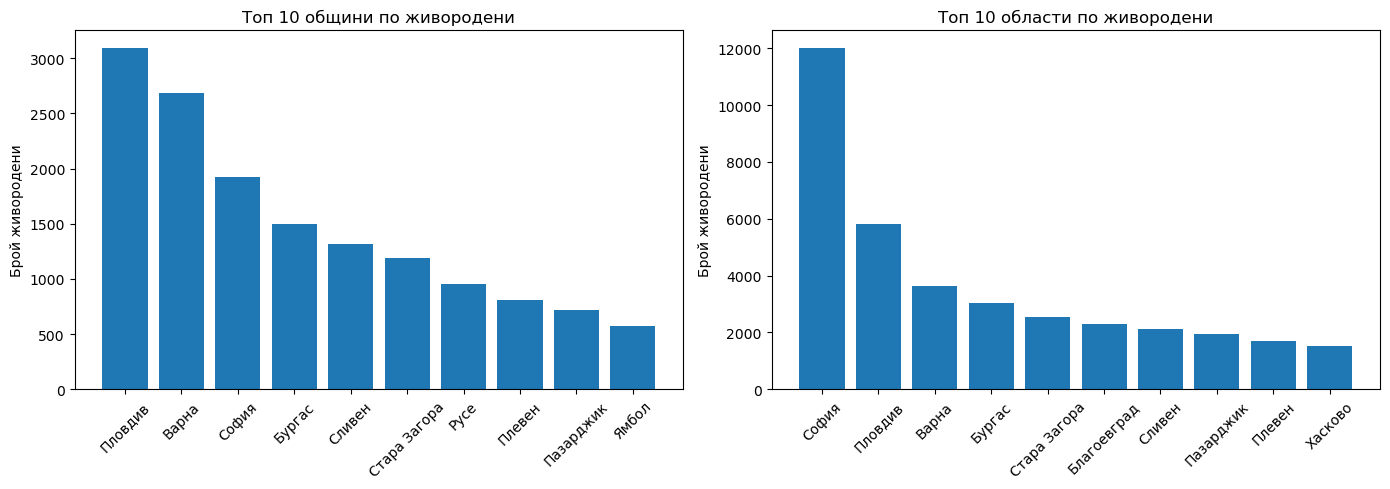

In [87]:
import matplotlib.pyplot as plt

top10_municipalities = top_n_places_by_births(df, n=10, level='municipality')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(top10_areas['Области, Общини'], top10_areas['общо'])
ax1.set_title('Топ 10 общини по живородени')
ax1.set_ylabel('Брой живородени')
ax1.tick_params(axis='x', rotation=45)

ax2.bar(top10_municipalities['Области, Общини'], top10_municipalities['общо'])
ax2.set_title('Топ 10 области по живородени')
ax2.set_ylabel('Брой живородени')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

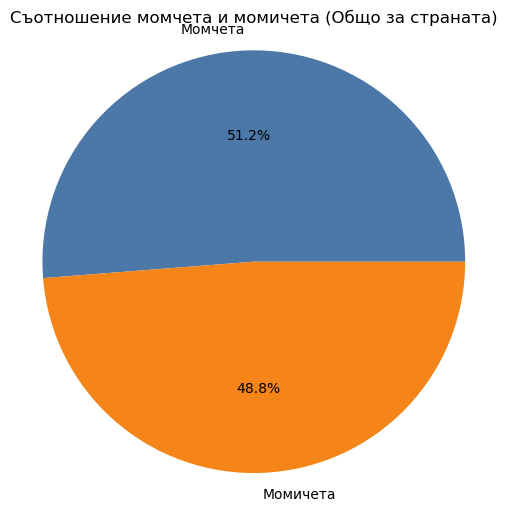

In [88]:
total_row = df[df['Области, Общини'].astype(str).str.strip() == 'Общо за страната'].iloc[0]

boys = pd.to_numeric(total_row['момчета'])
girls = pd.to_numeric(total_row['момичета'])

plt.figure(figsize=(6, 6))
plt.pie(
    [boys, girls],
    labels=['Момчета', 'Момичета'],
    autopct='%1.1f%%',
   
    colors=['#4C78A8', '#F58518'],
)
plt.title('Съотношение момчета и момичета (Общо за страната)')
plt.axis('equal')
plt.show()

## Таблица 2 - разпределение на живородени деца по възраст на майката


In [89]:
import pandas as pd

df = pd.read_excel(
    r"C:\Users\sasho kravaikov\Desktop\live_births\Live_births_by_districts_municipalities_and_age_of_mother.xlsx"
)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)


print(df)

       Области Общини   Общо под 20 20 - 24 25 - 29 30 - 34 35 - 39 40 - 44 45 + непоказана
0    Общо за страната  53428   5819    9873   13134   13847    8224    2019  509          3
1         Благоевград   2303    201     460     602     615     324      82   19          -
2              Банско     89      2      14      24      25      20       4    -          -
3              Белица     86     14      26      19      14      12       -    1          -
4         Благоевград    569     26      80     135     183     116      22    7          -
5         Гоце Делчев    253     17      49      87      66      25       5    4          -
6              Гърмен    160     18      51      45      30      12       4    -          -
7              Кресна     32      -       7       9       8       7       1    -          -
8              Петрич    385     54      83      85     110      36      16    1          -
9              Разлог    140     19      32      50      22      14       2    1

In [92]:
def top_age_group_for_country(df, place_col='Области Общини', total_label='Общо за страната'):
    row = df[df[place_col].astype(str).str.strip() == total_label].iloc[0]

    age_cols = [col for col in df.columns if col not in [place_col, 'Общо']]
    values = pd.to_numeric(row[age_cols])

    top_group = values.idxmax()
    top_value = int(values.max())
    return top_group, top_value


group, count = top_age_group_for_country(df)
print(f'Най-много живородени общо за страната има във възрастова група: {group} ({count})')

Най-много живородени общо за страната има във възрастова група: 30 - 34 (13847)


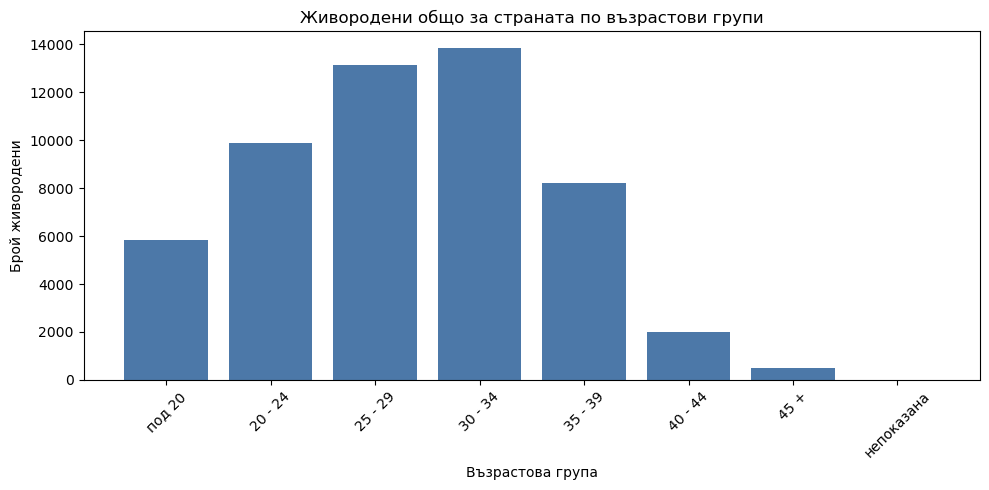

In [94]:
country_row = df[df['Области Общини'].astype(str).str.strip() == 'Общо за страната'].iloc[0]

age_groups = [col for col in df.columns if col not in ['Области Общини', 'Общо']]
values = pd.to_numeric(country_row[age_groups])

plt.figure(figsize=(10, 5))
plt.bar(age_groups, values, color='#4C78A8')
plt.title('Живородени общо за страната по възрастови групи')
plt.xlabel('Възрастова група')
plt.ylabel('Брой живородени')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [95]:
def top_municipality_under_20(df, place_col='Области Общини', age_col='под 20'):
    data = df[[place_col, age_col]].copy()
    data[age_col] = pd.to_numeric(data[age_col], errors='coerce')
    data = data.dropna(subset=[age_col])
    data = data[data[place_col].astype(str).str.strip() != 'Общо за страната']

    # При еднакво име оставяме по-малката стойност -> реда за община
    municipality_idx = data.groupby(place_col)[age_col].idxmin()
    municipalities = data.loc[municipality_idx].copy()

    top_row = municipalities.loc[municipalities[age_col].idxmax()]
    return top_row[place_col], int(top_row[age_col]), municipalities.sort_values(age_col, ascending=False)


mun_name, under20_count, under20_rank = top_municipality_under_20(df)
print(f'Общината с най-много живородени в група "под 20" е: {mun_name} ({under20_count})')
print('\nТоп 10 общини по живородени в група "под 20":')
print(under20_rank.head(10).to_string(index=False))

Общината с най-много живородени в група "под 20" е: Сливен (409)

Топ 10 общини по живородени в група "под 20":
Области Общини  под 20
        Сливен   409.0
         София   284.0
       Пловдив   219.0
         Ямбол   140.0
     Пазарджик   132.0
  Стара Загора   125.0
   Нова Загора   119.0
        Бургас   112.0
        Плевен   105.0
      Твърдица   104.0


## От горната таблица се вижда че макар и по малка община Сливен е с най-голям дял на младите майки. Значително повече от община София. Може да се направят съпоставки и анализи с други статестически данни, като дял на ромското население в общината но за сега няма да го правя(липсват ми достатъчно данни). 


---
## Табица 3 - Живородени брачни и извънбрачни по области, общини и местоживеене

In [97]:
import pandas as pd

df = pd.read_excel(
    r"C:\Users\sasho kravaikov\Desktop\live_births\Live_births_married_out-of-wedlock_districts_municipalities_and_place_of_residence.xlsx"
)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)


print(df)

       Области Общини Общо, всичко Общо, брачни Общо, извън-брачни В градовете, всичко В градовете, брачни В градовете, извън-брачни В селата, всичко В селата, брачни В селата, извън-брачни
0    Общо за страната        53428        20352              33076               39483               15928                     23555            13945             4424                   9521
1         Благоевград         2303         1127               1176                1432                 708                       724              871              419                    452
2              Банско           89           56                 33                  86                  53                        33                3                3                      -
3              Белица           86           27                 59                  33                  11                        22               53               16                     37
4         Благоевград          569          264   

## 3.1 Ранкинг по дял извънбрачни (над средното за страната)

Средно за страната (дял извънбрачни): 61.91%
Средно за страната (дял брачни): 38.09%

Топ 10 общини над националния дял (в пр.п.):
Области Общини  oow_share_pct  above_country_pp  Общо, всичко
      Твърдица      92.941176         31.033562         255.0
        Мъглиж      86.238532         24.330918         109.0
    Павел баня      84.558824         22.651210         136.0
      Стралджа      83.333333         21.425719         132.0
       Луковит      83.173077         21.265463         208.0
  Бяла Слатина      82.741117         20.833503         197.0
        Чирпан      82.352941         20.445327         204.0
       Тетевен      82.068966         20.161352         145.0
     Павликени      80.672269         18.764655         119.0
         Ловеч      79.919679         18.012065         249.0

Топ 10 области над националния дял (в пр.п.):
Области Общини  oow_share_pct  above_country_pp  Общо, всичко
      Твърдица      92.941176         31.033562         255.0
        Мъглиж  

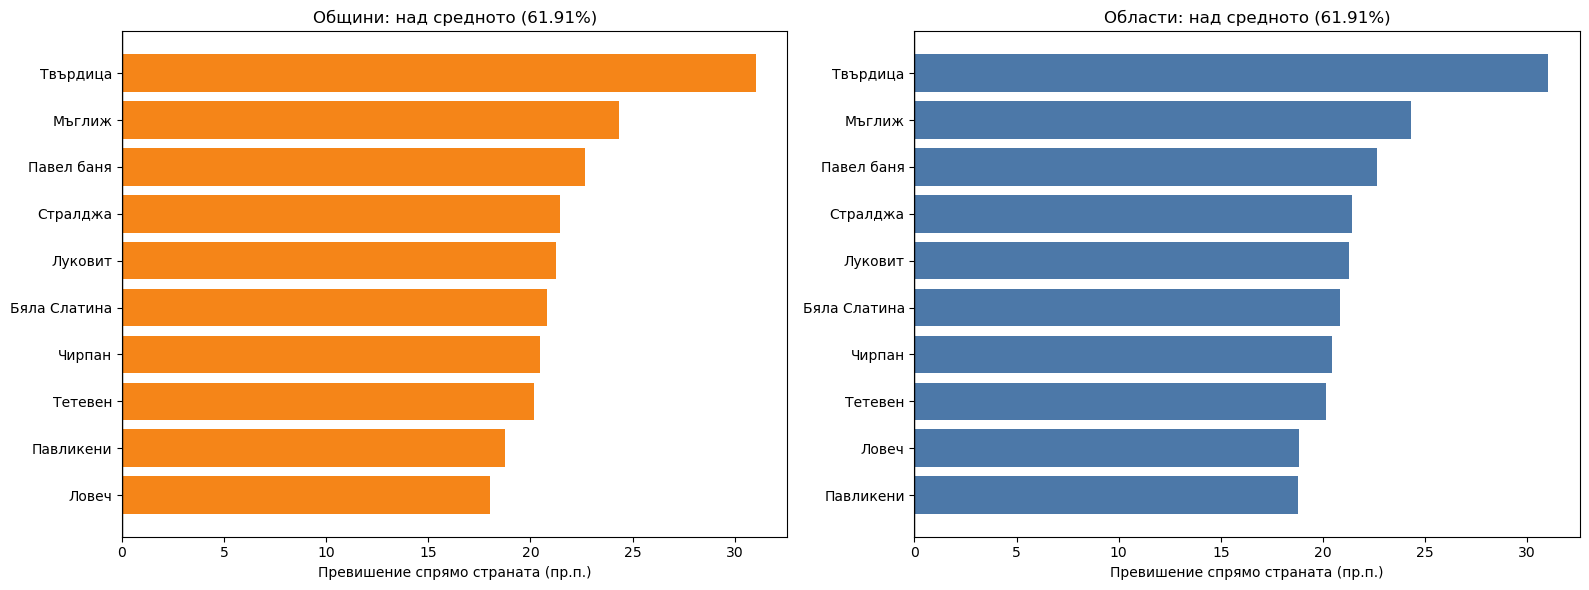

In [ ]:
import matplotlib.pyplot as plt

place_col = 'Области Общини'
total_col = 'Общо, всичко'
oow_col = 'Общо, извън-брачни'

data = df[[place_col, total_col, oow_col]].copy()
data[total_col] = pd.to_numeric(data[total_col], errors='coerce')
data[oow_col] = pd.to_numeric(data[oow_col], errors='coerce')
data = data.dropna(subset=[total_col, oow_col])

country = data[data[place_col].astype(str).str.strip() == 'Общо за страната'].iloc[0]
country_share = country[oow_col] / country[total_col]
country_share_pct = country_share * 100

local = data[data[place_col].astype(str).str.strip() != 'Общо за страната'].copy()

# Разделяме дублиращите имена: по-малка стойност = община, по-голяма = област
municipality_idx = local.groupby(place_col)[total_col].idxmin()
area_idx = local.groupby(place_col)[total_col].idxmax()

municipalities = local.loc[municipality_idx].copy()
areas = local.loc[area_idx].copy()

# Минимален праг за по-стабилни проценти
municipalities = municipalities[municipalities[total_col] >= 100]
areas = areas[areas[total_col] >= 100]

for frame in [municipalities, areas]:
    frame['дял_извънбрачни_%'] = (frame[oow_col] / frame[total_col]) * 100
    frame['над_средното_прп'] = frame['дял_извънбрачни_%'] - country_share_pct

top_municipalities = municipalities.sort_values('над_средното_прп', ascending=False).head(10)
top_areas = areas.sort_values('над_средното_прп', ascending=False).head(10)

print(f'Средно за страната (дял извънбрачни): {country_share_pct:.2f}%')
print(f'Средно за страната (дял брачни): {100 - country_share_pct:.2f}%')

print('\nТоп 10 общини над националния дял (в пр.п.):')
print(top_municipalities[[place_col, 'дял_извънбрачни_%', 'над_средното_прп', total_col]].to_string(index=False))

print('\nТоп 10 области над националния дял (в пр.п.):')
print(top_areas[[place_col, 'дял_извънбрачни_%', 'над_средното_прп', total_col]].to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.barh(top_municipalities[place_col], top_municipalities['над_средното_прп'], color='#F58518')
ax1.set_title(f'Общини: над средното ({country_share_pct:.2f}%)')
ax1.set_xlabel('Превишение спрямо страната (пр.п.)')
ax1.axvline(0, color='black', linewidth=1)
ax1.invert_yaxis()

ax2.barh(top_areas[place_col], top_areas['над_средното_прп'], color='#4C78A8')
ax2.set_title(f'Области: над средното ({country_share_pct:.2f}%)')
ax2.set_xlabel('Превишение спрямо страната (пр.п.)')
ax2.axvline(0, color='black', linewidth=1)
ax2.invert_yaxis()

plt.tight_layout()
plt.show()